Carleton School of Information Technology

Final project: Prompt Injection Detection Model Research

ITEC 5920 – Applied Deep Learning Winter 2026

Student: Michael Rolbin Student #100865849


## 1. Imports

In [ ]:
import re
import json
import warnings
import logging
import itertools
from pathlib import Path
from typing import Dict, List, Tuple

import glob
from huggingface_hub import snapshot_download
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import logging as _logging
import torch
from torch.utils.data import DataLoader
from torch.optim import AdamW

from datasets import load_dataset, DatasetDict
from huggingface_hub import snapshot_download
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
    set_seed,
    DataCollatorWithPadding,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve,
)

warnings.filterwarnings('ignore')
logging.disable(logging.WARNING)

## 2. Global Parameters

In [ ]:
SEED = 42
set_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

plt.style.use('seaborn-v0_8-whitegrid')
MODEL_COLORS = {
    'RoBERTa':    '#55A868',
    'DistilBERT': '#C44E52',
}

OUTPUT_DIR = Path('./results_hp_comparison')
OUTPUT_DIR.mkdir(exist_ok=True)


## 3. Per-Model Hyperparameter Grids

Each model has its own search space reflecting its architecture.
All **7 HPs** appear in every grid.

| HP | RoBERTa | DistilBERT | Rationale |
|---|---|---|---|
| `max_length` | 128, 256 | 128, 256 | Context vs. speed tradeoff |
| `batch_size` | 16, 32 | 16, 32 | Memory vs. throughput |
| `num_epochs` | 2, 3 | 3, 4 | Convergence budget |
| `learning_rate` | 2e-5, 3e-5 | 3e-5, 5e-5 | Architecture sensitivity |
| `weight_decay` | 0.0, 0.01 | 0.0, 0.01 | Regularisation |
| `warmup_ratio` | 0.06, 0.10 | 0.06, 0.10 | LR warmup fraction |
| `gradient_clip` | 1.0 | 1.0, 0.5 | Gradient stability |


In [ ]:
MODEL_HF_IDS = {
    'RoBERTa':    'roberta-base',
    'DistilBERT': 'distilbert-base-uncased',
}

#  Total iterations per model:
#    RoBERTa    : 2×2×2×2×2×2×1 = 64
#    DistilBERT : 2×2×2×2×2×2×2 = 128

MODEL_HP_GRIDS: Dict[str, Dict] = {

    'RoBERTa': {
        'max_length':    [128, 256],
        'batch_size':    [16, 32],
        'num_epochs':    [2, 3],
        'learning_rate': [2e-5, 3e-5],
        'weight_decay':  [0.0, 0.01],
        'warmup_ratio':  [0.06, 0.10],
        'gradient_clip': [1.0],
    },

    'DistilBERT': {
        'max_length':    [128, 256],
        'batch_size':    [16, 32],
        'num_epochs':    [3, 4],
        'learning_rate': [3e-5, 5e-5],
        'weight_decay':  [0.0, 0.01],
        'warmup_ratio':  [0.06, 0.10],
        'gradient_clip': [1.0, 0.5],
    },
}


## 4. Data Loading & Preprocessing

In [ ]:
# Download parquet files for the dataset
snapshot_dir = snapshot_download(
    repo_id='neuralchemy/Prompt-injection-dataset',
    repo_type='dataset',
    allow_patterns='*.parquet',
)
parquet_files = sorted(glob.glob(f'{snapshot_dir}/**/*.parquet', recursive=True))
print(f'Found {len(parquet_files)} parquet file(s):')
for p in parquet_files:
    print(f'  {p}')

Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

Found 7 parquet file(s):
  /root/.cache/huggingface/hub/datasets--neuralchemy--Prompt-injection-dataset/snapshots/895c8658ba32650917fd13bd209e03e2e5a6d568/core/test-00000-of-00001.parquet
  /root/.cache/huggingface/hub/datasets--neuralchemy--Prompt-injection-dataset/snapshots/895c8658ba32650917fd13bd209e03e2e5a6d568/core/train-00000-of-00001.parquet
  /root/.cache/huggingface/hub/datasets--neuralchemy--Prompt-injection-dataset/snapshots/895c8658ba32650917fd13bd209e03e2e5a6d568/core/validation-00000-of-00001.parquet
  /root/.cache/huggingface/hub/datasets--neuralchemy--Prompt-injection-dataset/snapshots/895c8658ba32650917fd13bd209e03e2e5a6d568/data/train-00000-of-00001.parquet
  /root/.cache/huggingface/hub/datasets--neuralchemy--Prompt-injection-dataset/snapshots/895c8658ba32650917fd13bd209e03e2e5a6d568/full/test-00000-of-00001.parquet
  /root/.cache/huggingface/hub/datasets--neuralchemy--Prompt-injection-dataset/snapshots/895c8658ba32650917fd13bd209e03e2e5a6d568/full/train-00000-of-00

In [ ]:
# Read each parquet file individually, normalise column names, and concatenate
KEEP_COLS = ['id', 'text', 'label', 'domain', 'subdomain']

frames = []
for path in parquet_files:
    df_part = pd.read_parquet(path)

    # Rename 'combined_text' to 'text'
    if 'combined_text' in df_part.columns and 'text' not in df_part.columns:
        df_part = df_part.rename(columns={'combined_text': 'text'})

    cols = [c for c in KEEP_COLS if c in df_part.columns]
    frames.append(df_part[cols])
    #print(f'  {path.split("/")[-1]:55s}  rows={len(df_part):6d}  cols={list(df_part.columns)}')

df_raw = pd.concat(frames, ignore_index=True)
print(f'\nTotal rows        : {len(df_raw)}')
print(f'Columns           : {list(df_raw.columns)}')
print(f'{df_raw["label"].value_counts().rename({0: "Benign", 1: "Harmful"}).to_string()}')


Total rows        : 32867
Columns           : ['text', 'label']
label
Harmful    16553
Benign     16314


In [ ]:
# NaN cleaning
df_no_nan = df_raw.dropna(subset=['text', 'label']).reset_index(drop=True)

def clean_text(text) -> str:
    if text is None or (isinstance(text, float) and (text != text)):
        return ''
    if not isinstance(text, str):
        text = str(text)
    text = text.strip()
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]', '', text)
    return text

def preprocess_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['text']  = df['text'].apply(clean_text)
    df['label'] = df['label'].astype(int)
    before = len(df)
    df = df[df['text'].str.len() > 0].drop_duplicates(subset=['text']).reset_index(drop=True)
    print(f'Rows: {before} to {len(df)}  (removed {before - len(df)} empty/duplicate)')
    return df[['text', 'label']]

df_clean = preprocess_dataframe(df_no_nan)
print(f'Clean dataset: {len(df_clean)} rows')
print(f'Label counts: {df_clean["label"].value_counts().rename({0: "Benign", 1: "Harmful"}).to_dict()}')

Rows: 22193 to 13215  (removed 8978 empty/duplicate)
Clean dataset: 13215 rows
Label counts: {'Harmful': 8434, 'Benign': 4781}


## 5. 80/20 Train-Test Split

In [ ]:
train_df, test_df = train_test_split(
    df_clean, test_size=0.20, stratify=df_clean['label'], random_state=SEED,
)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

n_harmful_train = int(train_df['label'].sum())
n_harmful_test  = int(test_df['label'].sum())
print(f'Train : {len(train_df)} samples  (harmful={n_harmful_train}, benign={len(train_df)-n_harmful_train})')
print(f'Test  : {len(test_df)} samples  (harmful={n_harmful_test}, benign={len(test_df)-n_harmful_test})')

Train : 10572 samples  (harmful=6747, benign=3825)
Test  : 2643 samples  (harmful=1687, benign=956)


## 6. Dataset & Metrics

In [ ]:
class InjectionDataset(torch.utils.data.Dataset):
    def __init__(self, dataframe: pd.DataFrame, tokenizer, max_length: int):
        self.texts      = dataframe['text'].tolist()
        self.labels     = dataframe['label'].tolist()
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self) -> int:
        return len(self.texts)

    def __getitem__(self, idx: int) -> Dict:
        enc = self.tokenizer(
            self.texts[idx], max_length=self.max_length,
            padding=False, truncation=True, return_tensors=None,
        )
        enc['labels'] = self.labels[idx]
        return enc


def compute_metrics(labels, preds, probs) -> Dict[str, float]:
    # Replace any NaN/Inf probs with 0.5 (neutral) before scoring
    probs = np.array(probs, dtype=np.float64)
    probs = np.where(np.isfinite(probs), probs, 0.5)
    probs = np.clip(probs, 0.0, 1.0)
    try:
        auc = roc_auc_score(labels, probs)
    except ValueError:
        auc = float('nan')
    return {
        'accuracy':  accuracy_score(labels, preds),
        'precision': precision_score(labels, preds, zero_division=0),
        'recall':    recall_score(labels, preds, zero_division=0),
        'f1':        f1_score(labels, preds, zero_division=0),
        'auc':       auc,
    }


def security_score(m: Dict[str, float]) -> float:
    # If any value is NaN drop it
    # and renormalise weights so score stays in [0, 1].
    components = [
        (m['recall'],   0.40),
        (m['f1'],       0.30),
        (m['auc'],      0.20),
        (m['accuracy'], 0.10),
    ]
    valid = [(v, w) for v, w in components if v == v]
    if not valid:
        return float('nan')
    total_w = sum(w for _, w in valid)
    return sum(v * w for v, w in valid) / total_w

## 7. Training Section

In [ ]:
ID2LABEL = {0: 'Benign', 1: 'Harmful'}
LABEL2ID = {'Benign': 0, 'Harmful': 1}


def _train_epoch(model, loader, optimizer, scheduler,
                   gradient_clip: float, loss_fn=None) -> float:
    model.train()
    total = 0.0
    for batch in loader:
        batch  = {k: v.to(DEVICE) for k, v in batch.items()}
        if loss_fn is not None:
            labels_t = batch.pop('labels')
            logits   = model(**batch).logits.float()
            loss     = loss_fn(logits, labels_t)
        else:
            loss = model(**batch).loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip)
        optimizer.step(); scheduler.step(); optimizer.zero_grad()
        total += loss.item()
    return total / len(loader)

@torch.no_grad()

def _eval(model, loader) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    for batch in loader:
        batch  = {k: v.to(DEVICE) for k, v in batch.items()}
        # We cast to fp32 in order to avoid NaN from bf16 overflow
        logits = model(**batch).logits.float()
        # We convert data to CPU in order to calculate NumPy
        all_probs.extend(torch.softmax(logits, -1)[:, 1].cpu().numpy())
        all_preds.extend(logits.argmax(-1).cpu().numpy())
        all_labels.extend(batch['labels'].cpu().numpy())
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)


def run_training(
    model_name:    str,

    # 7 hyperparameters
    max_length:    int,
    batch_size:    int,
    num_epochs:    int,
    learning_rate: float,
    weight_decay:  float,
    warmup_ratio:  float,
    gradient_clip: float,

    train_df: pd.DataFrame,
    test_df:  pd.DataFrame,
    verbose:  bool = False,
) -> Dict:
    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    collator  = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors='pt')

    train_loader = DataLoader(
        InjectionDataset(train_df, tokenizer, max_length),
        batch_size=batch_size, shuffle=True, collate_fn=collator, num_workers=0)
    test_loader = DataLoader(
        InjectionDataset(test_df, tokenizer, max_length),
        batch_size=batch_size * 2, shuffle=False, collate_fn=collator, num_workers=0)

    for _noisy in ('transformers.safetensors_conversion',
                   'huggingface_hub.utils._http',
                   'httpcore', 'httpx'):
        _logging.getLogger(_noisy).setLevel(_logging.CRITICAL)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=2,
        id2label=ID2LABEL, label2id=LABEL2ID,
        ignore_mismatched_sizes=True,
    ).to(DEVICE)

    optimizer    = AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    total_steps  = len(train_loader) * num_epochs
    scheduler    = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(total_steps * warmup_ratio),
        num_training_steps=total_steps)

    # Weighted cross-entropy to handle class imbalance
    # pos_weight = n_negative / n_positive
    labels_arr   = np.array(train_df['label'].tolist())
    n_pos        = max(labels_arr.sum(), 1)
    n_neg        = max(len(labels_arr) - n_pos, 1)
    pos_weight   = min(n_neg / n_pos, 10.0)
    pw_tensor    = torch.tensor([pos_weight], dtype=torch.float32, device=DEVICE)
    loss_fn      = torch.nn.BCEWithLogitsLoss(pos_weight=pw_tensor)

    def weighted_loss(logits, labels):
        return loss_fn(logits[:, 1] - logits[:, 0], labels.float())

    history = []
    best_f1, best_state = 0.0, None

    for epoch in range(1, num_epochs + 1):
        avg_loss = _train_epoch(model, train_loader, optimizer, scheduler,
                                gradient_clip, loss_fn=weighted_loss)
        labels, preds, probs = _eval(model, test_loader)
        m = compute_metrics(labels, preds, probs)
        history.append({'epoch': epoch, 'loss': avg_loss, **m})
        if verbose:
            print(f'    ep{epoch}  loss={avg_loss:.4f}  rec={m["recall"]:.4f}  '
                  f'f1={m["f1"]:.4f}  auc={m["auc"]:.4f}')
        if m['f1'] > best_f1:
            best_f1    = m['f1']
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    final_labels, final_preds, final_probs = _eval(model, test_loader)
    final_metrics = compute_metrics(final_labels, final_preds, final_probs)

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    hparams = dict(
        max_length=max_length, batch_size=batch_size, num_epochs=num_epochs,
        learning_rate=learning_rate, weight_decay=weight_decay,
        warmup_ratio=warmup_ratio, gradient_clip=gradient_clip,
    )
    return {
        'metrics':    final_metrics,
        'history':    history,
        'labels':     final_labels,
        'preds':      final_preds,
        'probs':      final_probs,
        'hparams':    hparams,
        'sec_score':  security_score(final_metrics),
        'cls_report': classification_report(
            final_labels, final_preds,
            target_names=['Benign', 'Harmful'], digits=4),
    }

## 8. Models' Evaluation

In [ ]:

# Every combination of each model's 7-HP grid is evaluated independently.
# The SECURITY score selects the winner.

HP_SEARCH_RESULTS: Dict[str, List[Dict]] = {}   # all runs per model

for model_label, grid in MODEL_HP_GRIDS.items():
    model_name = MODEL_HF_IDS[model_label]
    keys   = list(grid.keys())
    combos = list(itertools.product(*grid.values()))

    print(f'\n{"="*72}')
    print(f'  HP SEARCH: {model_label}  ({model_name})  — {len(combos)} combos')
    print(f'{"="*72}')

    runs: List[Dict] = []

    for i, combo in enumerate(combos, 1):
        hp = dict(zip(keys, combo))
        print(
            f'  [{i:3d}/{len(combos)}]  '
            f'lr={hp["learning_rate"]:.0e}  '
            f'wd={hp["weight_decay"]}  '
            f'wu={hp["warmup_ratio"]}  '
            f'ep={hp["num_epochs"]}  '
            f'bs={hp["batch_size"]}  '
            f'ml={hp["max_length"]}  '
            f'gc={hp["gradient_clip"]}',
            end='  … ',
        )
        try:
            result = run_training(
                model_name    = model_name,
                max_length    = hp['max_length'],
                batch_size    = hp['batch_size'],
                num_epochs    = hp['num_epochs'],
                learning_rate = hp['learning_rate'],
                weight_decay  = hp['weight_decay'],
                warmup_ratio  = hp['warmup_ratio'],
                gradient_clip = hp['gradient_clip'],
                train_df      = train_df,
                test_df       = test_df,
                verbose       = False,
            )
            runs.append(result)
            m = result['metrics']
            print(f'sec={result["sec_score"]:.4f}  '
                  f'rec={m["recall"]:.4f}  f1={m["f1"]:.4f}')
        except Exception as e:
            print(f'FAILED: {e}')

    HP_SEARCH_RESULTS[model_label] = runs
    if runs:
        best = max(runs, key=lambda r: r['sec_score'])
        print(f'\nBest for {model_label}: sec={best["sec_score"]:.4f}  '
              f'HP={best["hparams"]}')

print('\nPer-Model Evaluation complete.\n')


  HP SEARCH: RoBERTa  (roberta-base)  — 64 combos
  [  1/64]  lr=2e-05  wd=0.0  wu=0.06  ep=2  bs=16  ml=128  gc=1.0  … 

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

sec=0.9955  rec=0.9941  f1=0.9953
  [127/128]  lr=5e-05  wd=0.01  wu=0.1  ep=4  bs=32  ml=256  gc=1.0  … 

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

sec=0.9948  rec=0.9929  f1=0.9947
  [128/128]  lr=5e-05  wd=0.01  wu=0.1  ep=4  bs=32  ml=256  gc=0.5  … 

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

sec=0.9933  rec=0.9911  f1=0.9929

Best for DistilBERT: sec=0.9961  HP={'max_length': 128, 'batch_size': 32, 'num_epochs': 4, 'learning_rate': 5e-05, 'weight_decay': 0.0, 'warmup_ratio': 0.06, 'gradient_clip': 1.0}

Per-Model Evaluation complete.



## 9. Models' Evaluation Results

In [ ]:
BEST_RESULTS: Dict[str, Dict] = {}

for model_label, runs in HP_SEARCH_RESULTS.items():
    if not runs:
        print(f'{model_label}: no successful runs')
        continue

    rows = []
    for r in runs:
        row = {**r['hparams']}
        row.update({k.capitalize(): round(v, 4) for k, v in r['metrics'].items()})
        row['Security Score'] = round(r['sec_score'], 4)
        rows.append(row)

    df_hp = pd.DataFrame(rows).sort_values('Security Score', ascending=False)

    print(f'\n{"="*100}')
    print(f'  {model_label} — Results (top 10)')
    print(f'{"="*100}')
    print(df_hp.head(10).to_string(index=False))
    print(f'{"="*100}')

    fname = f'Results_{model_label.lower().replace("-", "_")}.csv'
    df_hp.to_csv(OUTPUT_DIR / fname, index=False)

    BEST_RESULTS[model_label] = max(runs, key=lambda r: r['sec_score'])


  RoBERTa — Results (top 10)
 max_length  batch_size  num_epochs  learning_rate  weight_decay  warmup_ratio  gradient_clip  Accuracy  Precision  Recall     F1    Auc  Security Score
        256          32           3        0.00002          0.00          0.10            1.0    0.9913     0.9946  0.9917 0.9932 0.9996          0.9937
        128          32           3        0.00003          0.00          0.06            1.0    0.9913     0.9946  0.9917 0.9932 0.9993          0.9936
        256          32           3        0.00003          0.00          0.06            1.0    0.9909     0.9946  0.9911 0.9929 0.9996          0.9933
        256          32           3        0.00002          0.00          0.06            1.0    0.9913     0.9964  0.9899 0.9932 0.9996          0.9930
        256          16           3        0.00002          0.01          0.06            1.0    0.9898     0.9929  0.9911 0.9920 0.9996          0.9929
        128          16           3        0.00003  

## 10. Hyperparameters Sensitivity Plots

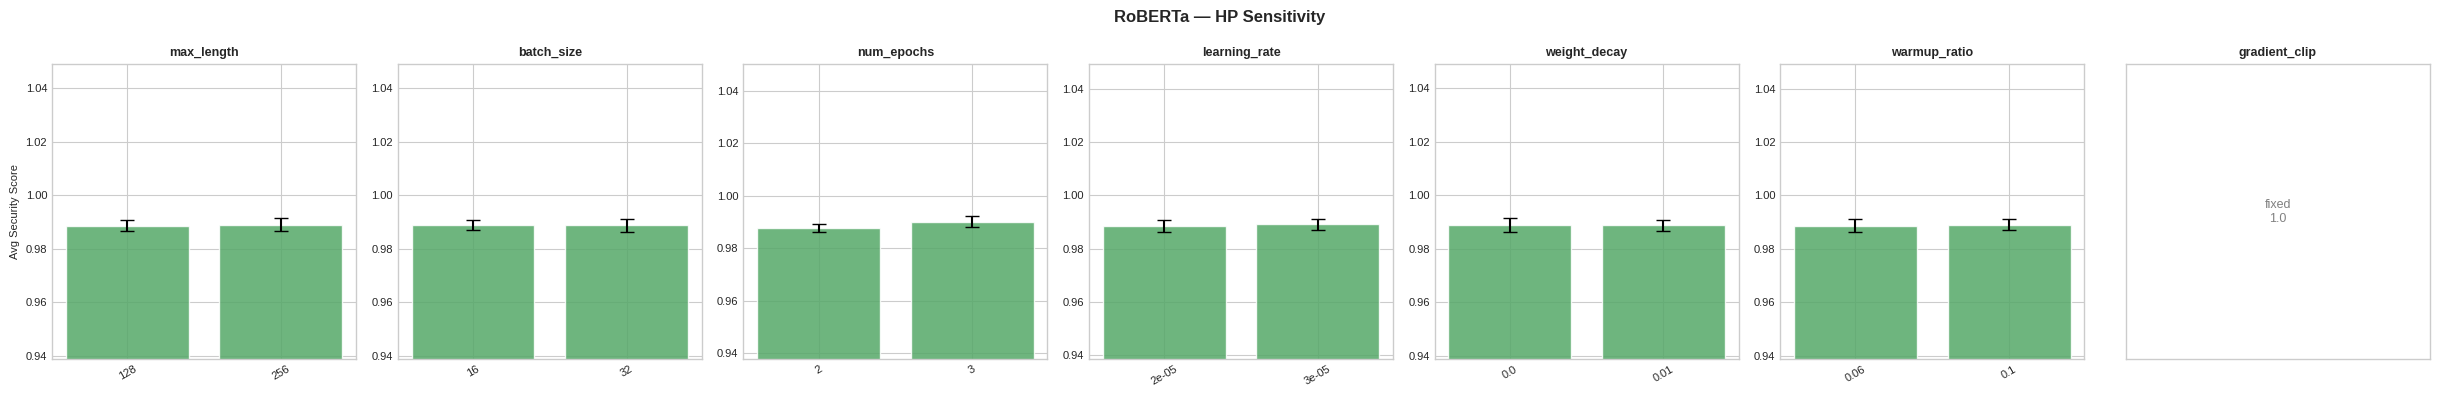

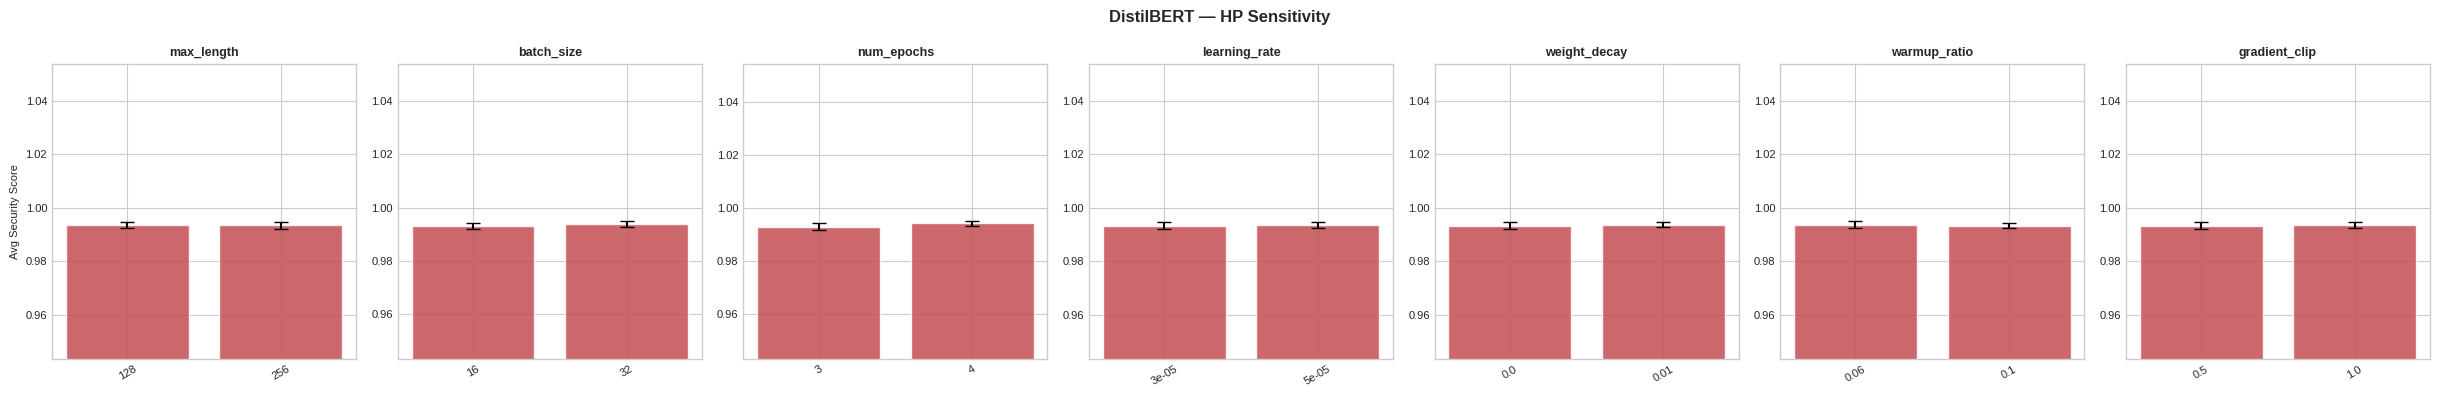

In [ ]:
HP_KEYS = ['max_length', 'batch_size', 'num_epochs', 'learning_rate',
           'weight_decay', 'warmup_ratio', 'gradient_clip']

for model_label, runs in HP_SEARCH_RESULTS.items():
    if not runs:
        continue

    df_sens  = pd.DataFrame([{**r['hparams'], 'sec_score': r['sec_score']} for r in runs])
    varied   = [hp for hp in HP_KEYS if df_sens[hp].nunique() > 1]
    color    = MODEL_COLORS.get(model_label, '#888888')

    fig, axes = plt.subplots(1, len(HP_KEYS), figsize=(3.5 * len(HP_KEYS), 4))

    for ax, hp_key in zip(axes, HP_KEYS):
        if df_sens[hp_key].nunique() > 1:
            grouped = df_sens.groupby(hp_key)['sec_score'].agg(['mean', 'std']).reset_index()
            ax.bar(
                grouped[hp_key].astype(str), grouped['mean'],
                yerr=grouped['std'], capsize=5,
                color=color, edgecolor='white', alpha=0.85,
            )
            lo = max(0, grouped['mean'].min() - 0.05)
            hi = grouped['mean'].max() + 0.06
            ax.set_ylim(lo, hi)
        else:
            ax.text(0.5, 0.5, f'fixed\n{df_sens[hp_key].iloc[0]}',
                    ha='center', va='center', transform=ax.transAxes,
                    fontsize=9, color='gray')
            ax.set_xticks([]); ax.set_yticks([])

        ax.set_title(hp_key, fontweight='bold', fontsize=9)
        ax.tick_params(axis='x', rotation=30, labelsize=8)
        ax.tick_params(axis='y', labelsize=8)
        if ax == axes[0]:
            ax.set_ylabel('Avg Security Score', fontsize=8)

    fig.suptitle(f'{model_label} — HP Sensitivity', fontsize=12, fontweight='bold')
    plt.tight_layout()
    fname = f'hp_sensitivity_{model_label.lower().replace("-", "_")}.png'
    plt.savefig(OUTPUT_DIR / fname, dpi=150, bbox_inches='tight')
    plt.show()

## 11. The Best Configuration Per Model

In [ ]:
print(f'{"="*80}')
print('  THE BEST CONFIGURATION PER MODEL')
print(f'{"="*80}')

summary_rows = []
for model_label, best in BEST_RESULTS.items():
    hp = best['hparams']
    m  = best['metrics']
    print(f'\n  ── {model_label} ──')
    for k, v in hp.items():
        val = f'{v:.2e}' if isinstance(v, float) and k == 'learning_rate' else str(v)
        print(f'    {k:<15s}: {val}')
    print(f'    {"─"*30}')
    print(f'    Security Score : {best["sec_score"]:.4f}')
    print(f'    Recall         : {m["recall"]:.4f}')
    print(f'    F1             : {m["f1"]:.4f}')
    print(f'    AUC            : {m["auc"]:.4f}')

    row = {'Model': model_label, **hp}
    row.update({k.capitalize(): round(v, 4) for k, v in m.items()})
    row['Security Score'] = round(best['sec_score'], 4)
    summary_rows.append(row)

best_summary_df = pd.DataFrame(summary_rows).sort_values('Security Score', ascending=False)
best_summary_df.to_csv(OUTPUT_DIR / 'best_hp_per_model.csv', index=False)

  THE BEST CONFIGURATION PER MODEL

  ── RoBERTa ──
    max_length     : 256
    batch_size     : 32
    num_epochs     : 3
    learning_rate  : 2.00e-05
    weight_decay   : 0.0
    warmup_ratio   : 0.1
    gradient_clip  : 1.0
    ──────────────────────────────
    Security Score : 0.9937
    Recall         : 0.9917
    F1             : 0.9932
    AUC            : 0.9996

  ── DistilBERT ──
    max_length     : 128
    batch_size     : 32
    num_epochs     : 4
    learning_rate  : 5.00e-05
    weight_decay   : 0.0
    warmup_ratio   : 0.06
    gradient_clip  : 1.0
    ──────────────────────────────
    Security Score : 0.9961
    Recall         : 0.9959
    F1             : 0.9950
    AUC            : 0.9997


## 12. Cross-Model Comparison

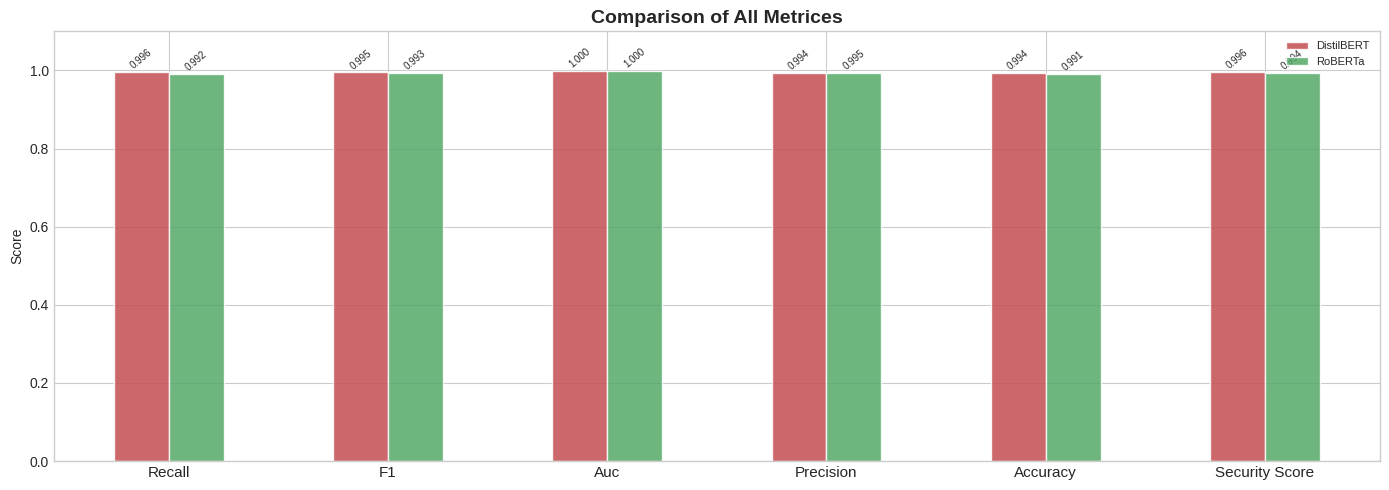

In [ ]:
# All Metrics
metric_cols = ['Recall', 'F1', 'Auc', 'Precision', 'Accuracy', 'Security Score']
x     = np.arange(len(metric_cols))
n     = len(best_summary_df)
bar_w = 0.25

fig, ax = plt.subplots(figsize=(14, 5))
for i, (_, row) in enumerate(best_summary_df.iterrows()):
    offsets = (i - (n - 1) / 2) * bar_w
    bars = ax.bar(
        x + offsets,
        [row[mc] for mc in metric_cols],
        width=bar_w, label=row['Model'],
        color=MODEL_COLORS.get(row['Model'], '#888'), alpha=0.85, edgecolor='white',
    )
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.003,
                f'{h:.3f}', ha='center', va='bottom', fontsize=7, rotation=40)

ax.set_xticks(x)
ax.set_xticklabels(metric_cols, fontsize=11)
ax.set_ylabel('Score'); ax.set_ylim(0, 1.10)
ax.set_title('Comparison of All Metrices', fontweight='bold', fontsize=14)
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'comparison_all_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

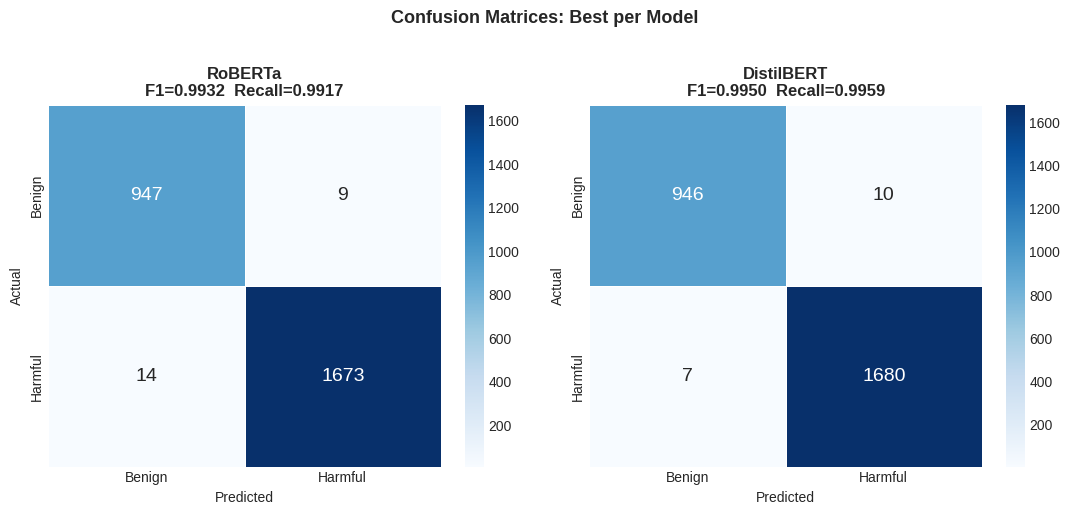

In [ ]:
# Confusion Matrices
n_models = len(BEST_RESULTS)
fig, axes = plt.subplots(1, n_models, figsize=(5.5 * n_models, 5))
if n_models == 1:
    axes = [axes]

for ax, (model_label, best) in zip(axes, BEST_RESULTS.items()):
    cm = confusion_matrix(best['labels'], best['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Benign', 'Harmful'],
                yticklabels=['Benign', 'Harmful'],
                linewidths=0.5, annot_kws={'size': 14})
    m = best['metrics']
    ax.set_title(f'{model_label}\nF1={m["f1"]:.4f}  Recall={m["recall"]:.4f}',
                 fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices: Best per Model', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'comparison_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

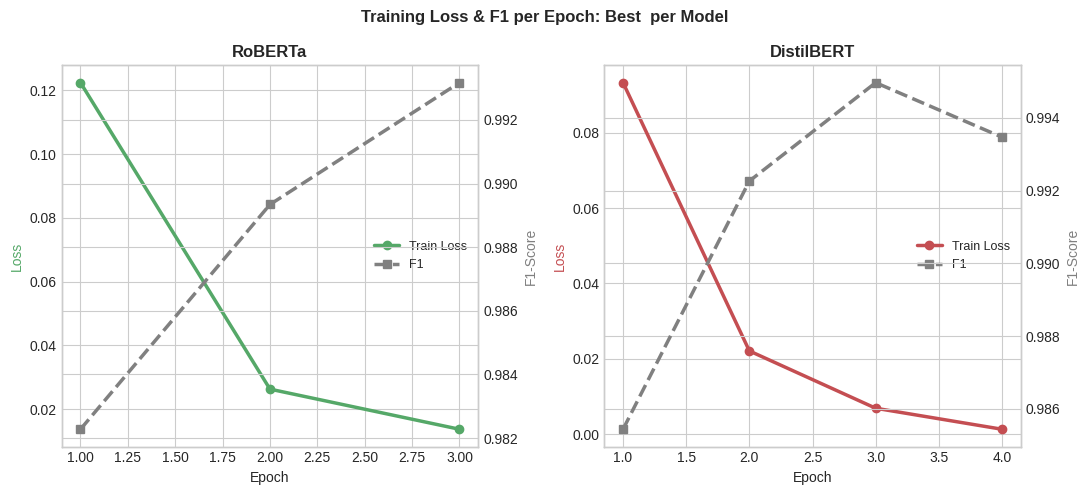

In [ ]:
# Training Loss & F1 per model
fig, axes = plt.subplots(1, len(BEST_RESULTS), figsize=(5.5 * len(BEST_RESULTS), 5))
if len(BEST_RESULTS) == 1:
    axes = [axes]

for ax, (model_label, best) in zip(axes, BEST_RESULTS.items()):
    color  = MODEL_COLORS.get(model_label, '#888')
    epochs = [h['epoch'] for h in best['history']]
    losses = [h['loss']  for h in best['history']]
    f1s    = [h['f1']    for h in best['history']]

    ax2 = ax.twinx()
    ax.plot(epochs, losses, '-o', linewidth=2.5, color=color,   label='Train Loss')
    ax2.plot(epochs, f1s,   '-s', linewidth=2.5, color='gray', linestyle='--', label='F1')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss', color=color)
    ax2.set_ylabel('F1-Score', color='gray')
    ax.set_title(f'{model_label}', fontweight='bold')
    l1, lb1 = ax.get_legend_handles_labels()
    l2, lb2 = ax2.get_legend_handles_labels()
    ax.legend(l1 + l2, lb1 + lb2, loc='center right', fontsize=9)

plt.suptitle('Training Loss & F1 per Epoch: Best  per Model',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'comparison_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

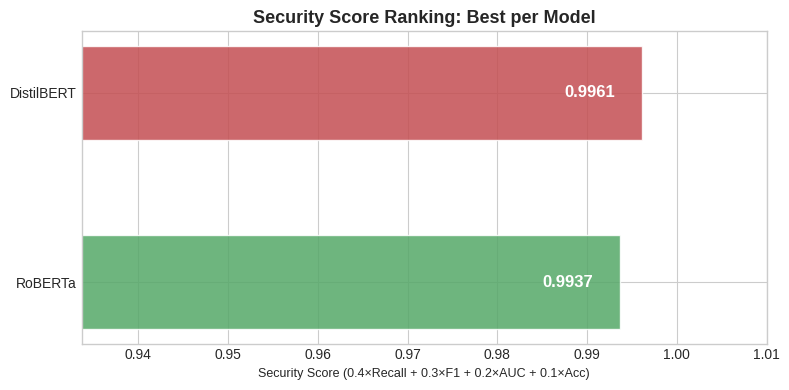

In [ ]:
# Security Score
fig, ax = plt.subplots(figsize=(8, 4))
models = best_summary_df['Model'].tolist()
scores = best_summary_df['Security Score'].tolist()
colors = [MODEL_COLORS.get(m, '#888') for m in models]

bars = ax.barh(models, scores, color=colors, alpha=0.85, edgecolor='white', height=0.5)
for bar, score in zip(bars, scores):
    ax.text(score - 0.003, bar.get_y() + bar.get_height() / 2,
            f'{score:.4f}', ha='right', va='center',
            fontsize=12, color='white', fontweight='bold')

lo = max(0, min(scores) - 0.06)
ax.set_xlim(lo, 1.01)
ax.set_xlabel('Security Score (0.4×Recall + 0.3×F1 + 0.2×AUC + 0.1×Acc)', fontsize=9)
ax.set_title('Security Score Ranking: Best per Model', fontweight='bold', fontsize=13)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'comparison_security_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

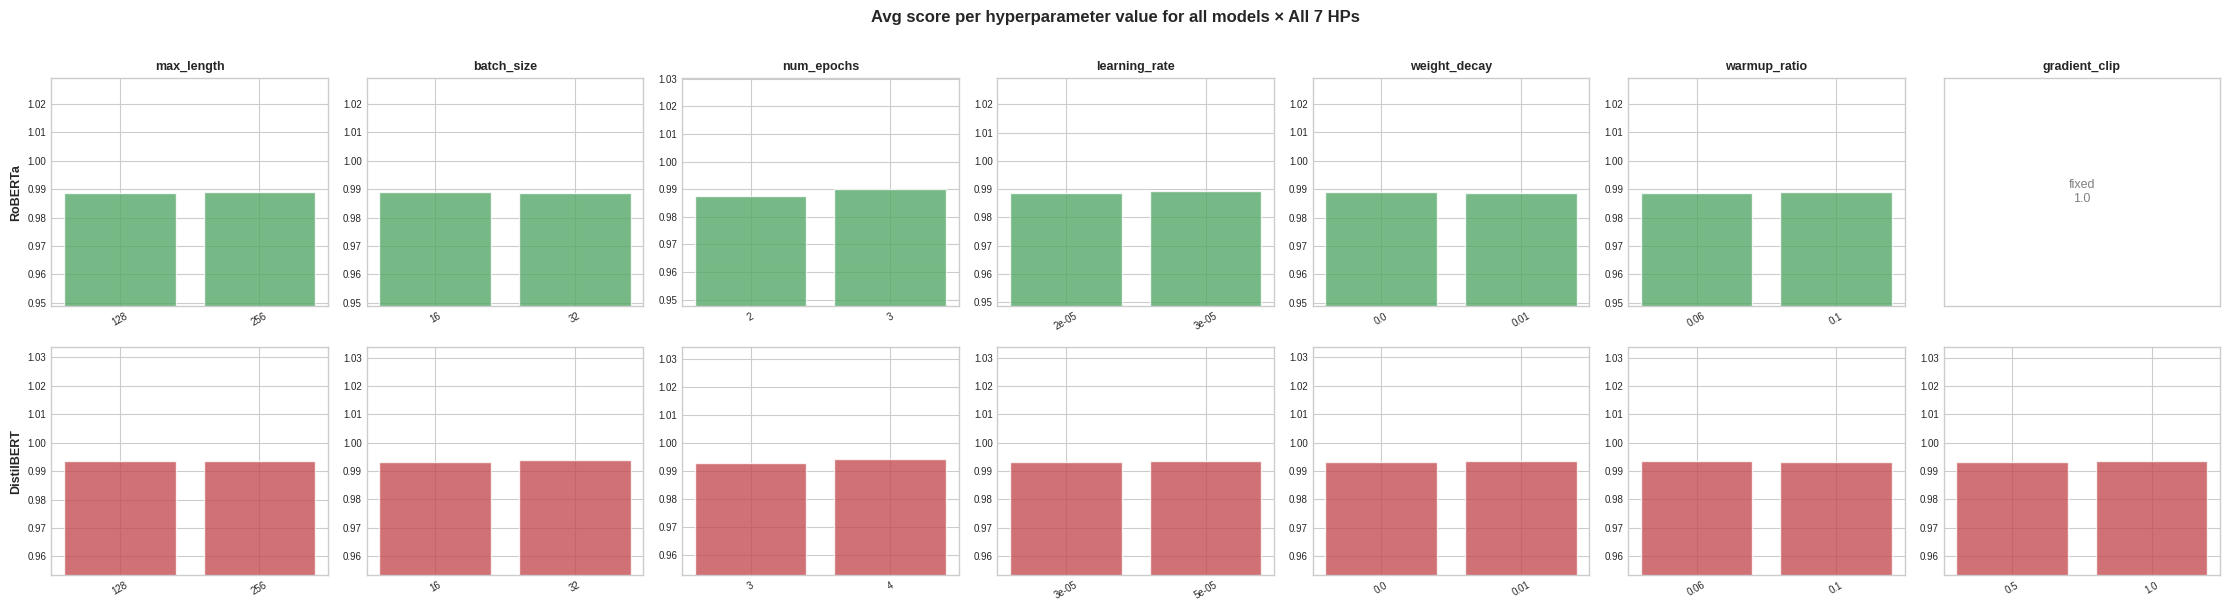

In [ ]:
# Avg score per hyperparameter value for all models
fig, outer = plt.subplots(
    len(HP_SEARCH_RESULTS), len(HP_KEYS),
    figsize=(3.2 * len(HP_KEYS), 3.0 * len(HP_SEARCH_RESULTS)),
)

for row_i, (model_label, runs) in enumerate(HP_SEARCH_RESULTS.items()):
    if not runs:
        continue
    df_all = pd.DataFrame([{**r['hparams'], 'sec_score': r['sec_score']} for r in runs])
    color  = MODEL_COLORS.get(model_label, '#888')

    for col_i, hp_key in enumerate(HP_KEYS):
        ax = outer[row_i][col_i]
        if df_all[hp_key].nunique() > 1:
            g = df_all.groupby(hp_key)['sec_score'].mean()
            ax.bar(g.index.astype(str), g.values, color=color, alpha=0.8, edgecolor='white')
            ax.set_ylim(max(0, g.min() - 0.04), g.max() + 0.04)
        else:
            ax.text(0.5, 0.5, f'fixed\n{df_all[hp_key].iloc[0]}',
                    ha='center', va='center', transform=ax.transAxes,
                    fontsize=9, color='gray')
            ax.set_xticks([]); ax.set_yticks([])

        ax.tick_params(axis='x', rotation=30, labelsize=7)
        ax.tick_params(axis='y', labelsize=7)
        if col_i == 0:
            ax.set_ylabel(model_label, fontsize=9, fontweight='bold')
        if row_i == 0:
            ax.set_title(hp_key, fontsize=9, fontweight='bold')

plt.suptitle('Avg score per hyperparameter value for all models × All 7 HPs',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'hp_grid_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Detailed Classification Reports

In [ ]:
for model_label, best in BEST_RESULTS.items():
    m  = best['metrics']
    hp = best['hparams']
    print(f'\n{"="*65}')
    print(f'  {model_label} — Classification Report')
    print(f'  HP: {hp}')
    print(f'{"="*65}')
    print(best['cls_report'])
    print(f'  Security Score : {best["sec_score"]:.4f}')
    print(f'  (0.4×Recall + 0.3×F1 + 0.2×AUC + 0.1×Accuracy)')


  RoBERTa — Classification Report
  HP: {'max_length': 256, 'batch_size': 32, 'num_epochs': 3, 'learning_rate': 2e-05, 'weight_decay': 0.0, 'warmup_ratio': 0.1, 'gradient_clip': 1.0}
              precision    recall  f1-score   support

      Benign     0.9854    0.9906    0.9880       956
     Harmful     0.9946    0.9917    0.9932      1687

    accuracy                         0.9913      2643
   macro avg     0.9900    0.9911    0.9906      2643
weighted avg     0.9913    0.9913    0.9913      2643

  Security Score : 0.9937
  (0.4×Recall + 0.3×F1 + 0.2×AUC + 0.1×Accuracy)

  DistilBERT — Classification Report
  HP: {'max_length': 128, 'batch_size': 32, 'num_epochs': 4, 'learning_rate': 5e-05, 'weight_decay': 0.0, 'warmup_ratio': 0.06, 'gradient_clip': 1.0}
              precision    recall  f1-score   support

      Benign     0.9927    0.9895    0.9911       956
     Harmful     0.9941    0.9959    0.9950      1687

    accuracy                         0.9936      2643
   macro